In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyts.decomposition import SingularSpectrumAnalysis

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from matplotlib.collections import PolyCollection
import math

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

In [3]:
# series = data['missforest_precipitation'].apply(lambda x: math.log(x+1)).values
series = np.log1p(data['missforest_precipitation'].values)


L = 10
n_comp = 10

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

X_ssa = series.reshape(1, -1)
series_reshaped = series.reshape(1, -1)
all_components = ssa.fit_transform(series_reshaped)

# all_components forma po fit_transform yra (1, L, len(series))
# Ištraukiame tik komponentes:
components = all_components[0]

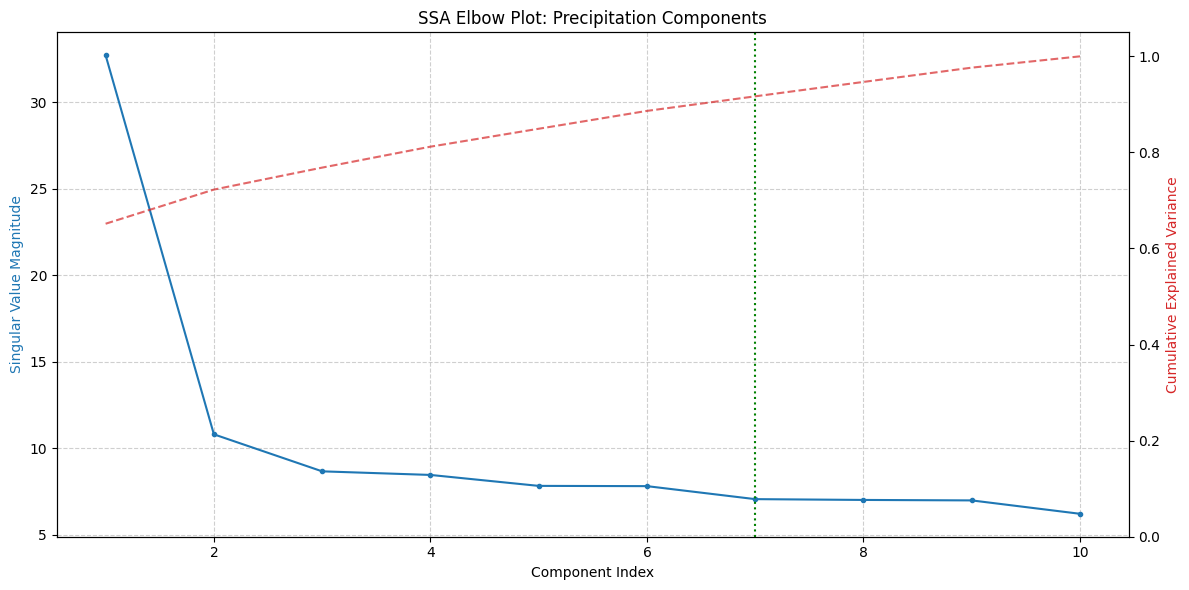

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you are using pyts.decomposition.SingularSpectrumAnalysis
# We need the singular values. If the library doesn't expose them directly, 
# we can compute them from the trajectory matrix or use the component energy.

# 1. Calculate the 'energy' of each component (sum of squares)
# This is proportional to the singular values squared
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

fig.tight_layout()
plt.show()

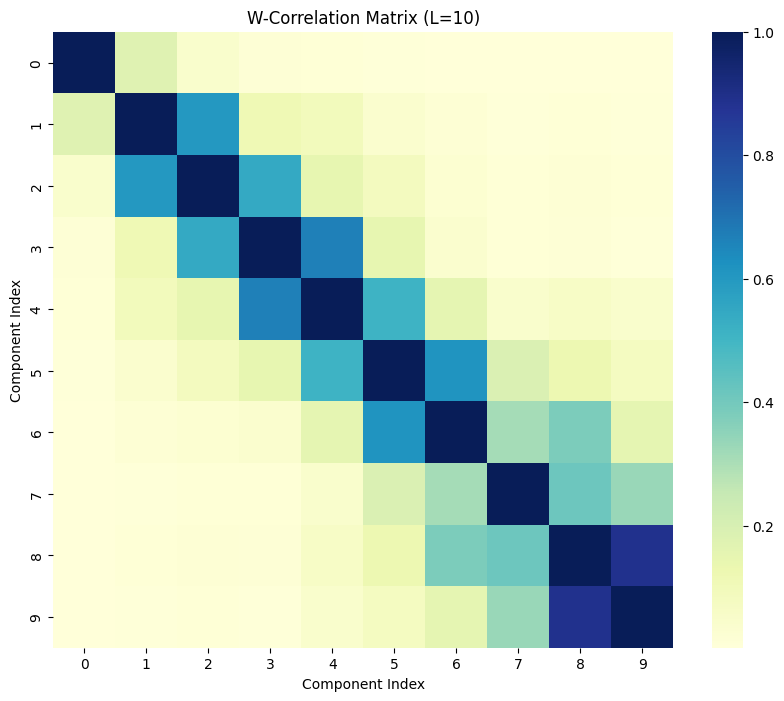

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

C:\Users\crist\AppData\Local\Temp\ipykernel_31580\1136780807.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


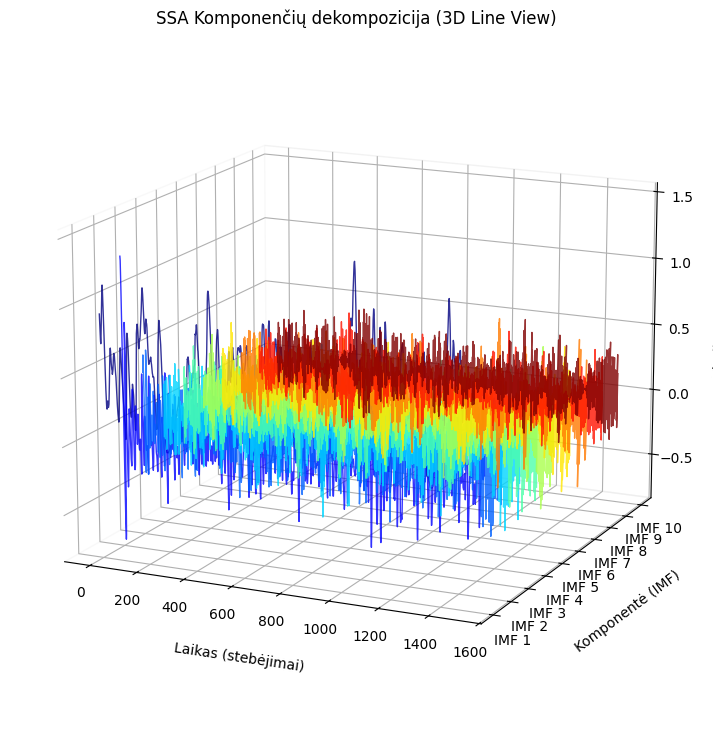

In [6]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(n_comp)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, n_comp))

for i in range(n_comp):
    y = components[i][:n_points]
    # Kiekvieną komponentę nubraižome kaip liniją tam tikrame gylio (z) lygmenyje
    # Naudojame plot() funkciją, kur y ašis (gylis) yra konstanta 'i'
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

# 3. Estetika ir kampas (kad būtų kaip image_4a4242.jpg)
ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

# Kameros nustatymai: 
# elev (aukštis virš horizonto) - mažesnis skaičius žiūri labiau iš priekio
# azim (pasukimas aplink Z ašį) - nustatykite pagal tai, kiek "šono" norite matyti
ax.view_init(elev=15, azim=-65) 

# Nuimame pilką foną, kad būtų švariau (panašiai kaip pavyzdyje)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Nustatome y ašies žymas (komponenčių numerius)
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.tight_layout()
plt.show()

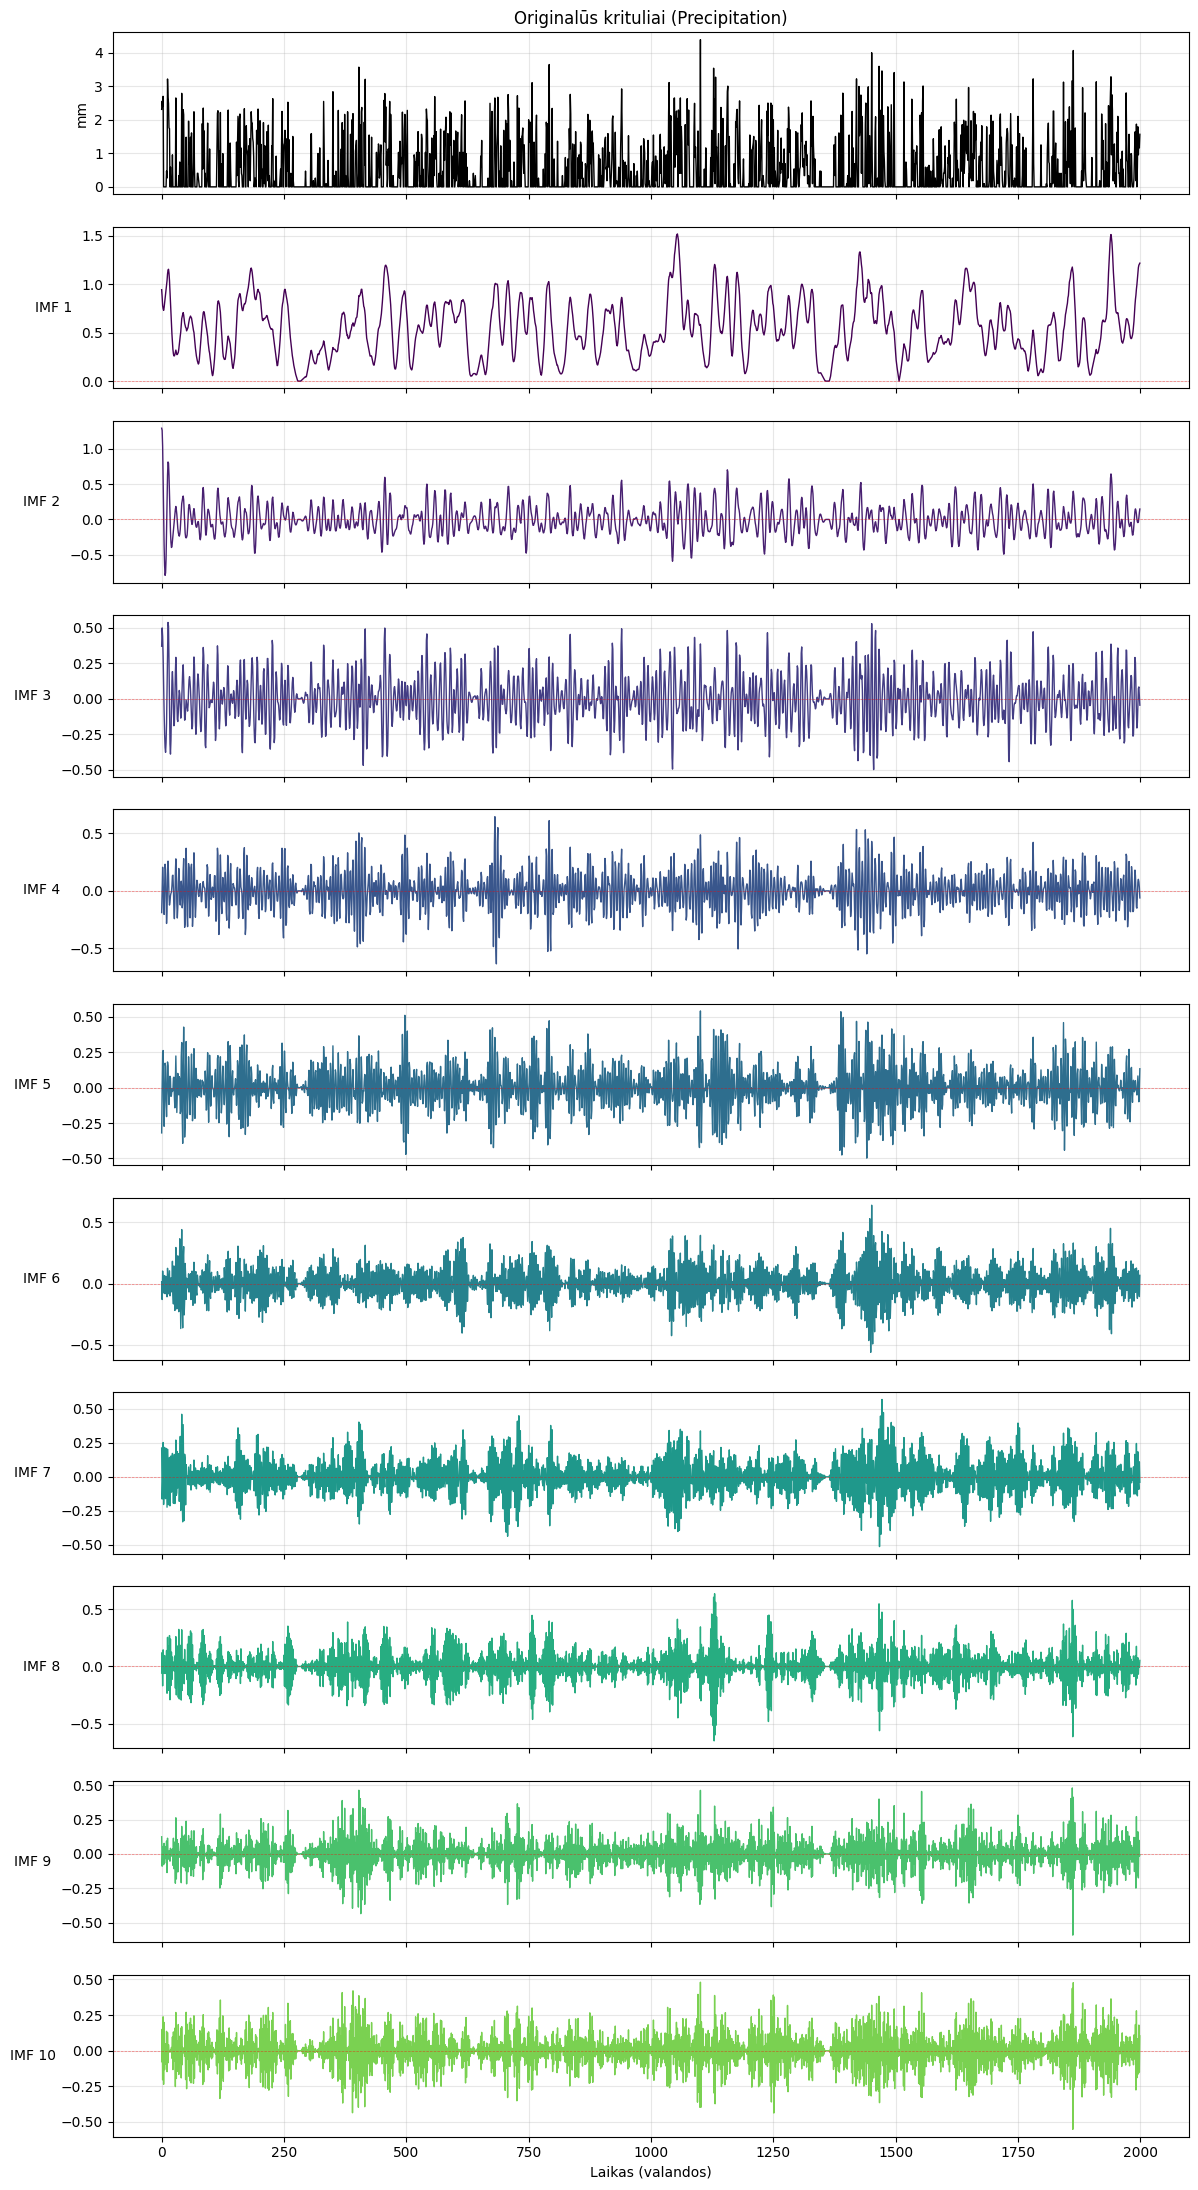

In [7]:
fig, axes = plt.subplots(n_comp + 1, 1, figsize=(12, 2 * (n_comp + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, n_comp))

for i in range(n_comp):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

 Komponentės   RMSE  R2 Score
Real vs Real 0.0000    1.0000
       IMF 1 0.7093    0.2301
 IMF 1 iki 2 0.6341    0.3846
 IMF 1 iki 3 0.5764    0.4916
 IMF 1 iki 4 0.5150    0.5941
 IMF 1 iki 5 0.4594    0.6770
 IMF 1 iki 6 0.3966    0.7593
 IMF 1 iki 7 0.3313    0.8320
 IMF 1 iki 8 0.2450    0.9081
 IMF 1 iki 9 0.1342    0.9725
IMF 1 iki 10 0.0000    1.0000


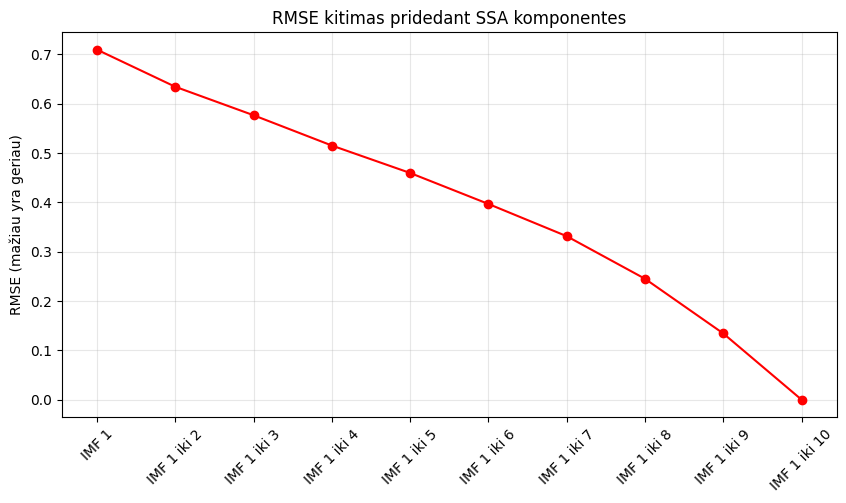

In [8]:
rmse_results = []
current_reconstruction = np.zeros_like(series)

for i in range(n_comp):
    # Pridedame sekančią komponentę
    current_reconstruction += components[i]
    
    # Skaičiuojame metrikas lyginant su originaliu 'series'
    rmse = np.sqrt(mean_squared_error(series, current_reconstruction))
    r2 = r2_score(series, current_reconstruction)
    
    label = "IMF 1" if i == 0 else f"IMF 1 iki {i+1}"
    rmse_results.append({
        "Komponentės": label,
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

# Pridedame "Real vs Real" (kontrolinis variantas)
rmse_results.insert(0, {
    "Komponentės": "Real vs Real", 
    "RMSE": 0.0000, 
    "R2 Score": 1.0000
})

# 3. Išvedame lentelę
df_rmse = pd.DataFrame(rmse_results)
print(df_rmse.to_string(index=False))

# 4. (Papildomai) Vizualizacija, kad matytumėte "lūžio tašką"
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_rmse["Komponentės"][1:], df_rmse["RMSE"][1:], marker='o', linestyle='-', color='red')
plt.title("RMSE kitimas pridedant SSA komponentes")
plt.ylabel("RMSE (mažiau yra geriau)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

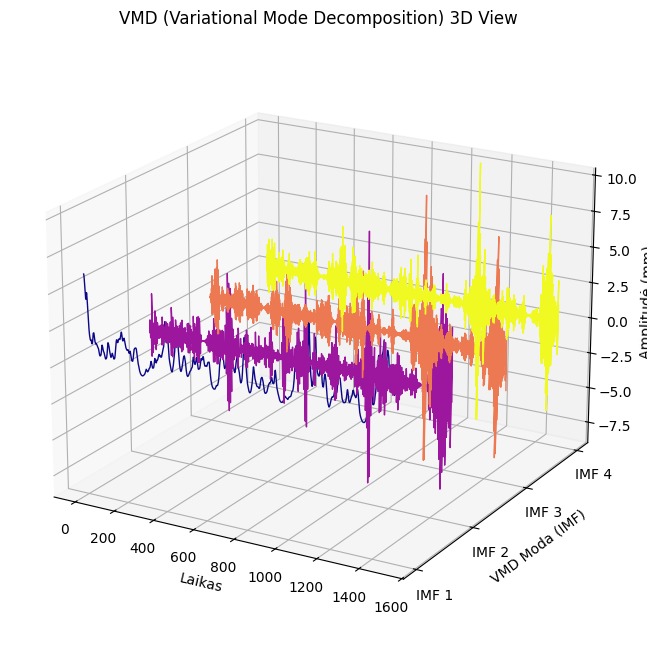

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD

# 1. Duomenų paruošimas
# data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
series = data['missforest_precipitation'].values

# 2. VMD Parametrai
alpha = 2000       # Duomenų vientisumo svoris (mažesnis alpha = platesnė juosta)
tau = 0.           # Laiko žingsnis (0 triukšmingiems duomenims)
K = 4              # Modų skaičius (kiek dalių norime gauti)
DC = 0             # Ar įtraukti nuolatinę komponentę (0 - ne)
init = 1           # Dažnių inicializacija (1 - vienodai paskirstyti)
tol = 1e-7         # Tolerancijos riba

# Atliekame dekompoziciją
u, u_hat, omega = VMD(series, alpha, tau, K, DC, init, tol)

# 3. 3D Waterfall Grafikas (VMD)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(K)
colors = plt.cm.plasma(np.linspace(0, 1, K))

for i in range(K):
    # 'u' masyve saugomos VMD komponentės (modos)
    y = u[i, :n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1)

ax.set_xlabel('Laikas')
ax.set_ylabel('VMD Moda (IMF)')
ax.set_zlabel('Amplitudė (mm)')
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])
ax.view_init(elev=20, azim=-60)

plt.title("VMD (Variational Mode Decomposition) 3D View")
plt.show()

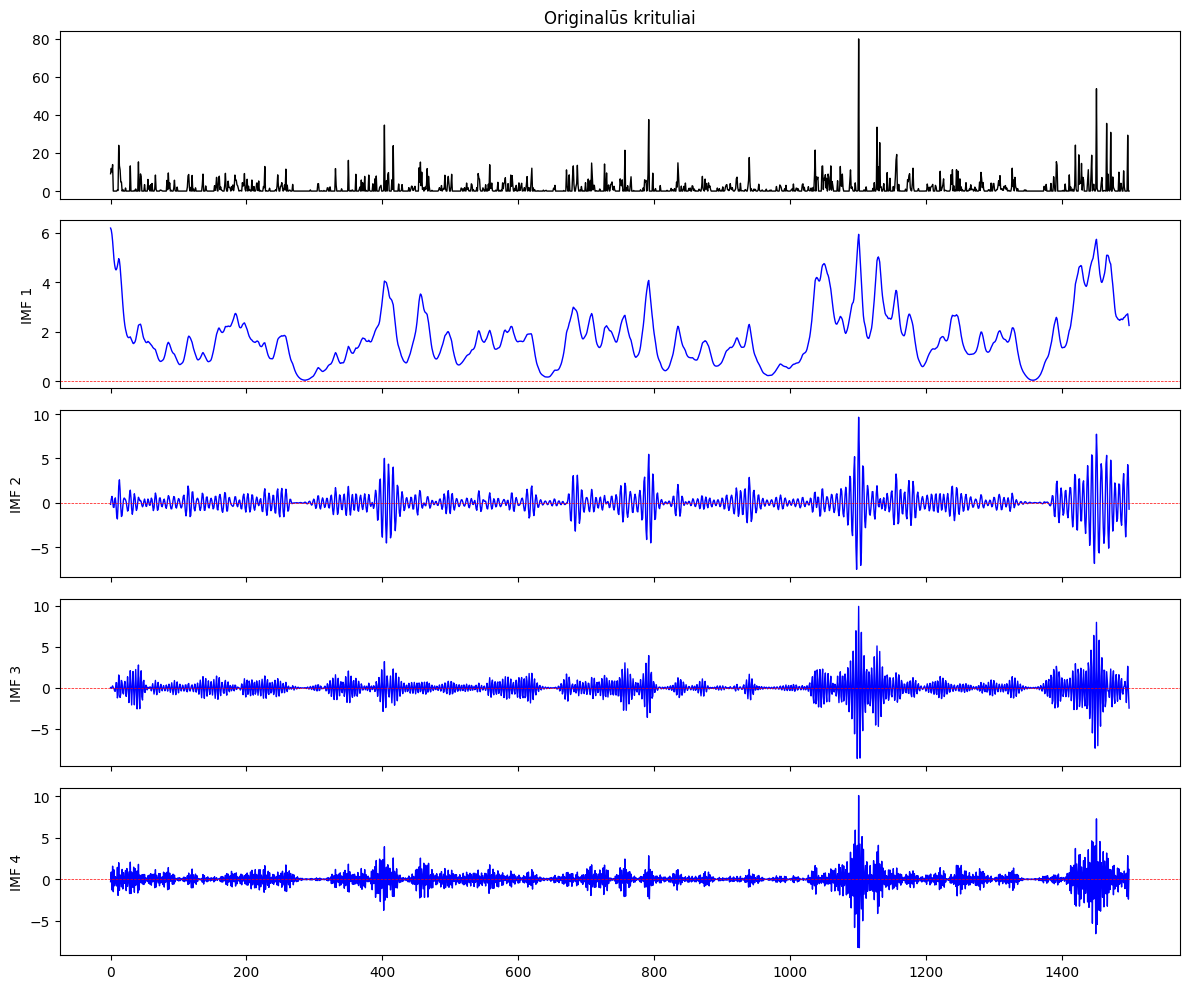

In [10]:
fig, axes = plt.subplots(K + 1, 1, figsize=(12, 2 * (K + 1)), sharex=True)

# Originalas
axes[0].plot(series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai')

# VMD Modos
for i in range(K):
    axes[i+1].plot(u[i, :n_points], color='blue', linewidth=1)
    axes[i+1].set_ylabel(f'IMF {i+1}')
    axes[i+1].axhline(0, color='red', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_results = []
reconstructed = np.zeros_like(series)

print(f"{'VMD Modos':<15} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 40)

for i in range(K):
    reconstructed += u[i, :]
    rmse = np.sqrt(mean_squared_error(series, reconstructed))
    r2 = r2_score(series, reconstructed)
    
    label = f"IMF 1-{i+1}"
    print(f"{label:<15} | {rmse:>10.4f} | {r2:>10.4f}")

VMD Modos       | RMSE       | R2 Score  
----------------------------------------
IMF 1-1         |     4.1943 |     0.1347
IMF 1-2         |     3.7538 |     0.3069
IMF 1-3         |     3.3147 |     0.4596
IMF 1-4         |     2.8460 |     0.6016


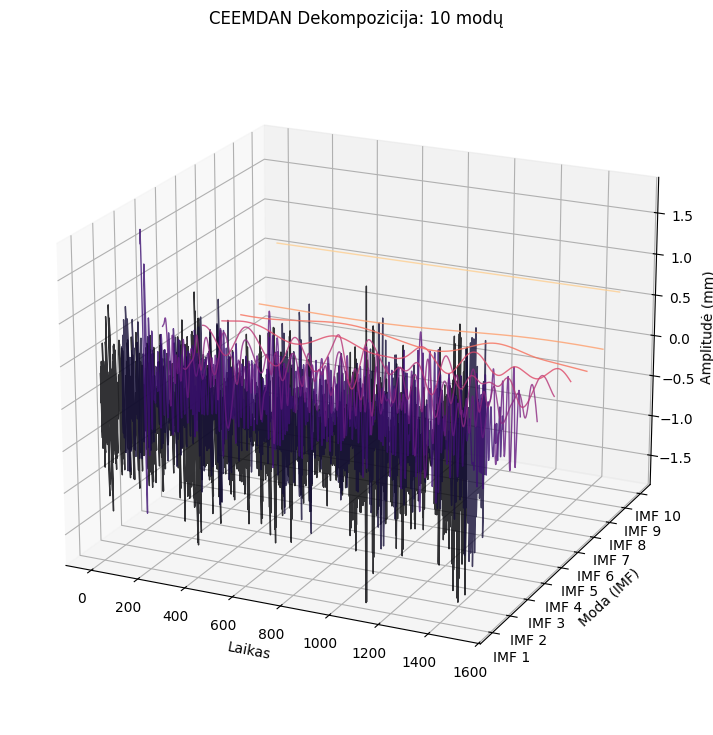

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import CEEMDAN

# 1. Duomenų paruošimas
# data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
series = np.log1p(data['missforest_precipitation'].values)
time = np.arange(len(series))

# 2. CEEMDAN dekompozicija
# Pastaba: CEEMDAN gali užtrukti ilgiau nei SSA ar VMD dėl ansamblinio triukšmo pridėjimo
ceemdan = CEEMDAN()
imfs = ceemdan(series)
n_imfs = imfs.shape[0]

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(n_imfs)
colors = plt.cm.magma(np.linspace(0, 0.9, n_imfs))

for i in range(n_imfs):
    y = imfs[i, :n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

ax.set_xlabel('Laikas')
ax.set_ylabel('Moda (IMF)')
ax.set_zlabel('Amplitudė (mm)')
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])
ax.view_init(elev=20, azim=-65)

plt.title(f"CEEMDAN Dekompozicija: {n_imfs} modų")
plt.show()

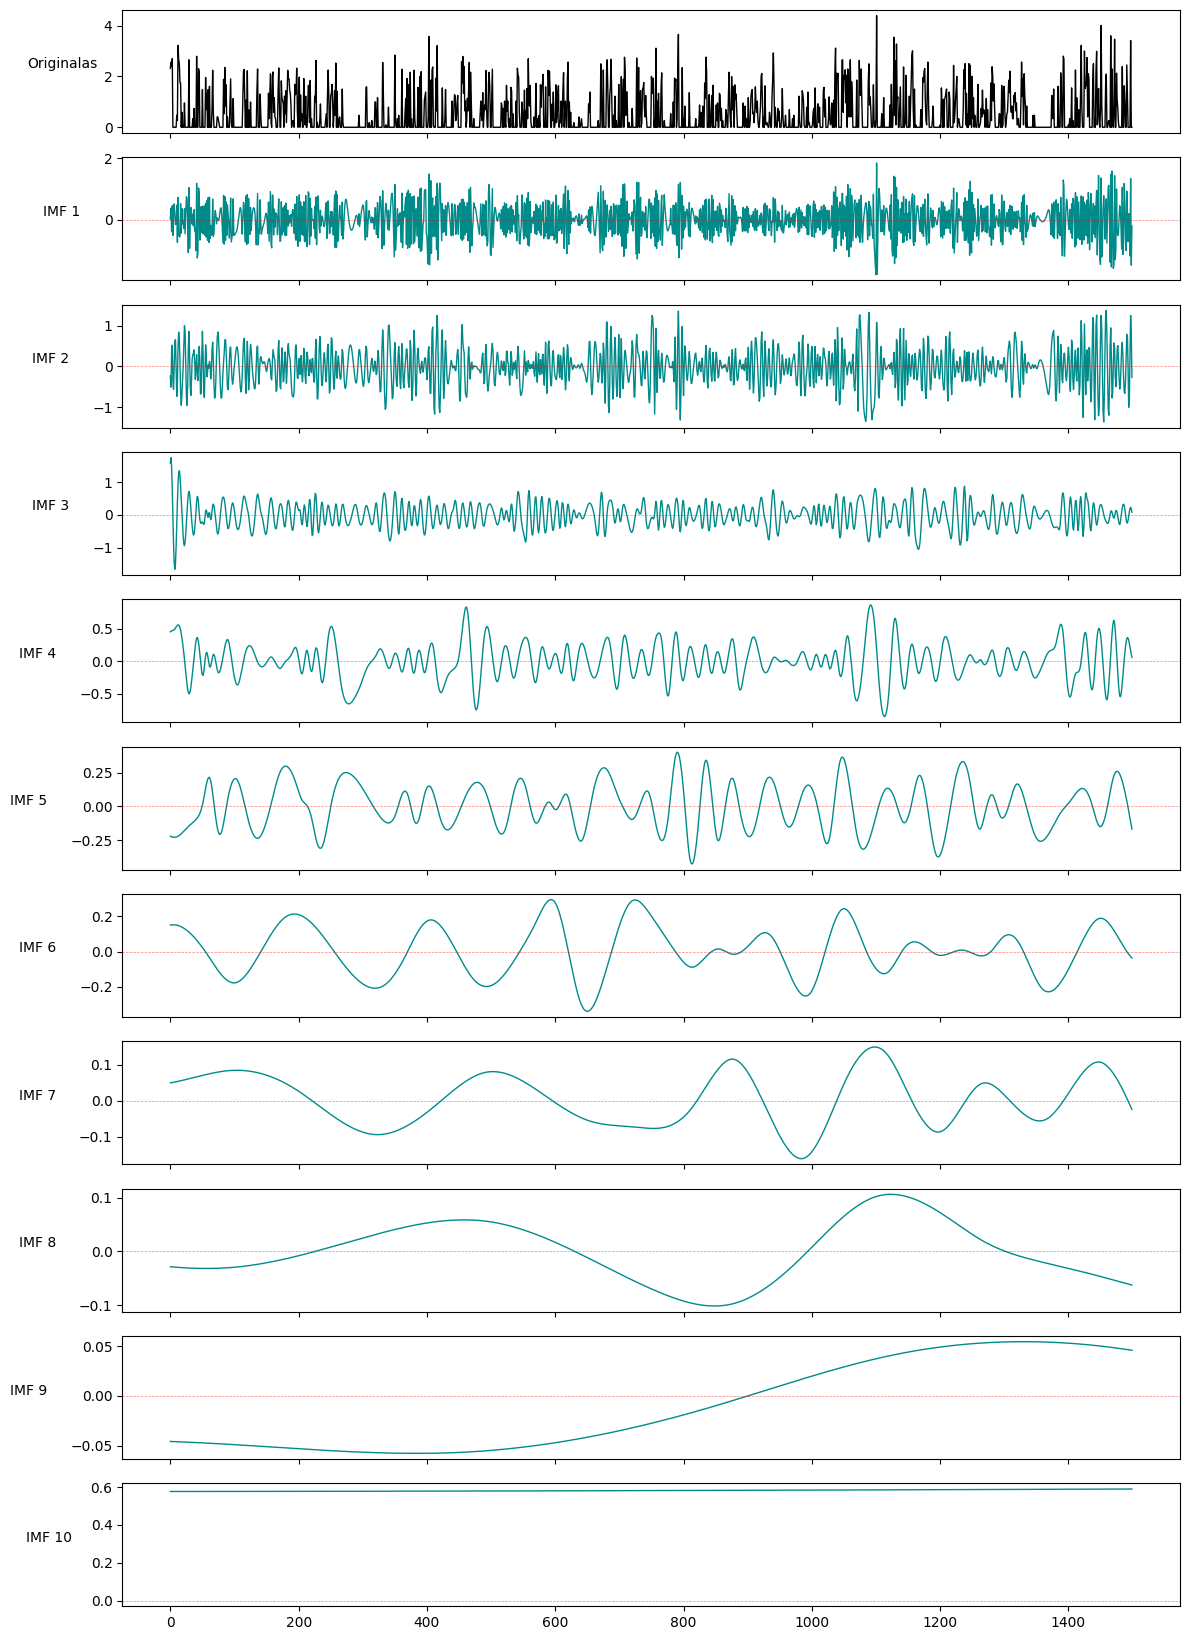

In [4]:
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(12, 1.5 * (n_imfs + 1)), sharex=True)

# Originalas
axes[0].plot(series[:n_points], color='black', linewidth=1)
axes[0].set_ylabel('Originalas', rotation=0, labelpad=30)

# CEEMDAN IMF
for i in range(n_imfs):
    axes[i+1].plot(imfs[i, :n_points], color='darkcyan', linewidth=1)
    axes[i+1].set_ylabel(f'IMF {i+1}', rotation=0, labelpad=30)
    axes[i+1].axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_results = []
reconstructed = np.zeros_like(series)

print(f"{'IMF Progresija':<15} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 45)

for i in range(n_imfs):
    reconstructed += imfs[i, :]
    rmse = np.sqrt(mean_squared_error(series, reconstructed))
    r2 = r2_score(series, reconstructed)
    
    label = f"IMF 1 iki {i+1}"
    print(f"{label:<15} | {rmse:>10.4f} | {r2:>10.4f}")

IMF Progresija  | RMSE       | R2 Score  
---------------------------------------------
IMF 1 iki 1     |     4.7511 |    -0.1103
IMF 1 iki 2     |     3.6493 |     0.3450
IMF 1 iki 3     |     3.0968 |     0.5283
IMF 1 iki 4     |     2.5151 |     0.6889
IMF 1 iki 5     |     2.3209 |     0.7351
IMF 1 iki 6     |     2.1642 |     0.7696
IMF 1 iki 7     |     2.0271 |     0.7979
IMF 1 iki 8     |     1.9109 |     0.8204
IMF 1 iki 9     |     1.8816 |     0.8259
IMF 1 iki 10    |     1.8569 |     0.8304
IMF 1 iki 11    |     1.8796 |     0.8262
IMF 1 iki 12    |     0.0000 |     1.0000
